# Где живёт joint-SVD компонента и как сделать её достаточной

Этот ноутбук продолжает только SVD-часть `18_DefenseMechanismPresentation.ipynb` и
математическую постановку из `Method_Mathematical.md`. Он отвечает на четыре вопроса:

1. Насколько joint-компонента плотна по нейронам, слоям и spatial cells — в среднем и на 5 реальных изображениях?
2. Как растёт достаточность при постепенном возвращении всё большей части реальной дельты?
3. Совпадает ли компонента с нейронами, важными по layer Integrated Gradients?
4. Как выглядит обратная проекция компоненты на входные пиксели — отдельно и поверх изображения?

**Единица анализа.** Только воспроизводимо скрытые target instances из прежней functional subset.
**Причинная метрика достаточности.** В clean endpoint добавляется выбранная часть реальной
`patched − clean` feature-delta; успех означает, что фиксированный clean target после обычных
decode + NMS снова скрыт.

Ноутбук рассчитан на локальный запуск. Тяжёлая ячейка помечена отдельно и сохраняет компактный
cache по каждому примеру, поэтому повторный запуск пропускает уже готовые изображения.

In [1]:
from pathlib import Path
import json
import math
import os
import sys
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/patch_success_matplotlib")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import PercentFormatter
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

HERE = Path.cwd().resolve()
if HERE.name != "CandidateRoutingAndAttackPath":
    HERE = HERE / "CandidateRoutingAndAttackPath"
REPO = HERE.parent
for path in (REPO, REPO / "new_experiments"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

PREVIOUS = HERE / "followup_outputs" / "full_success_2a6617f59d1bed77"
CACHE = HERE / "followup_outputs" / "svd_component_followup_joint_ig_v2"
CACHE.mkdir(parents=True, exist_ok=True)

DEVICE = "mps"          # замените на "cuda" или "cpu" при необходимости
MAX_EXAMPLES = None      # None = все 45 hidden endpoints; 5 удобно для smoke run
N_VISUAL = 5
PATH_STEPS = 5           # как в основном full-success run
PIXEL_IG_STEPS = 8
RESIDUAL_BUDGETS = np.array([0, .001, .003, .01, .03, .10, .30, .60, 1.0])
FORCE_RECOMPUTE = False

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.titlesize": 13})
BLUE, ORANGE, GREEN, RED, PURPLE, GRAY = (
    "#457B9D", "#F4A261", "#2A9D8F", "#E76F51", "#7B2CBF", "#6C757D"
)

assert PREVIOUS.exists(), f"Не найден прежний run: {PREVIOUS}"
print(f"Cache: {CACHE}")

Cache: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/followup_outputs/svd_component_followup_joint_ig_v2


## Отправная точка: что уже установлено

Для каждого FPN-уровня строился path-integrated joint-якобиан выбранных
`[person logits, decoded IoU]` по локальным Detect-input активациям:

$$J_l^{joint}=U_l\Sigma_lV_l^\top,\qquad
\delta_l^J=V_{l,r}V_{l,r}^\top\delta_l.$$

Здесь $\delta_l=h_l^{patched}-h_l^{clean}$, а $V_{l,r}$ содержит все численно
ненулевые правые сингулярные направления. Важно: $\delta_l^J$ — не «один нейрон»
и не обязательно sparse-вектор. Это часть **реально наблюдаемой** дельты,
попавшая в row-space функций target reserve.

Ниже сначала воспроизводятся ключевые старые числа, затем компонента раскладывается
обратно в координаты `[layer, channel, y, x]`.

In [2]:
joint = pd.read_csv(PREVIOUS / "joint_functional_summary.csv")
old = joint[
    joint.analysis_group.eq("all")
    & joint.condition.isin(["joint_rowspace", "full_candidate_windows", "full_maps"])
].copy()
old.pivot_table(
    index="condition", columns="direction",
    values=["mean_component_energy_fraction", "recovery_rate", "reproduced_hiding_rate"]
).round(4)

mean_component_energy_fraction                   \
direction                              repair_patched transplant_clean   
condition                                                                
full_candidate_windows                         0.0915           0.0915   
full_maps                                      1.0000           1.0000   
joint_rowspace                                 0.0029           0.0029   

                        recovery_rate                  reproduced_hiding_rate  \
direction              repair_patched transplant_clean         repair_patched   
condition                                                                       
full_candidate_windows            1.0           0.0667                    0.0   
full_maps                         1.0           0.0000                    0.0   
joint_rowspace                    1.0           0.5111                    0.0   

                                         
direction              transplant_clean  
condition                                
full_candidate_windows           0.9333  
full_maps                        1.0000  
joint_rowspace                   0.4889

## Определения новых измерений

- **Нейрон** — одна координата `(channel, y, x)` на одном FPN-уровне.
- **Spatial cell** — `(y, x)`, агрегированная по всем каналам как сумма квадратов.
- **Support@q** — минимальная доля координат, содержащая `q` энергии компоненты.
- **Participation ratio** $=(\sum a_i^2)^2/\sum a_i^4$ — эффективное число
  задействованных координат без произвольного порога.
- **Score-only layer IG importance** для нейрона $j$:

  $$IG_j=\delta_j\frac1S\sum_s
  \frac{\partial \bar z_{reserve}(h^c+\alpha_s\delta)}{\partial h_j}.$$

  Это контрольный layer Integrated Gradients вдоль того же clean→patched пути.
- **Joint-norm IG** использует ровно те же строки `[person logits, decoded IoU]`, что SVD:

  $$I_j^{norm}=|\delta_j|\,\|\bar J_{:,j}^{joint}\|_2.$$

  Он нужен для unsigned overlap: насколько нейрон способен менять весь joint-набор.
- **Joint-aligned IG** ориентирует joint-якобиан вдоль наблюдаемого изменения outputs:

  $$w={\bar J\delta\over\|\bar J\delta\|_2},\qquad
  I_j^{aligned}=\delta_j\,w^\top\bar J_{:,j}.$$

  Он сохраняет знак и используется для causal expansion. Здесь намеренно сохранён тот же
  ненормированный joint-якобиан, что в SVD; поэтому сравнение не меняет исходную постановку.

In [3]:
import torch
import torch.nn.functional as F

from CandidateRoutingAndAttackPath.attack_path import _capture_detect_inputs, _preprocess_pair
from CandidateRoutingAndAttackPath.candidate_reserve import _cache_lookup, _evaluate_batch
from CandidateRoutingAndAttackPath.causal_repair import _load_inputs
from CandidateRoutingAndAttackPath.common import load_experiment, release_accelerator_memory
from CandidateRoutingAndAttackPath.followup_common import ATTACK_PATH_DB, MANIFEST_CSV, TRACE_DB
from CandidateRoutingAndAttackPath.full_success_closure import (
    FullSuccessClosureConfig, _candidate_closure, _local_indices, _path_jacobians,
)
from CandidateRoutingAndAttackPath.mechanism_followup import _head_branches
from segmentig_detector.yolo_utils import get_detect_module, safe_model_forward


def numerical_svd(jacobian, delta):
    if jacobian.size == 0:
        return np.empty((0, len(delta))), np.empty(0), np.zeros_like(delta), 0
    _u, singular, vh = np.linalg.svd(jacobian.astype(np.float64), full_matrices=False)
    tol = max(jacobian.shape) * np.finfo(np.float64).eps * max(float(singular.max()), 1.0)
    rank = int((singular > tol).sum())
    basis = vh[:rank]
    component = basis.T @ (basis @ delta.astype(np.float64))
    return basis, singular[:rank], component.astype(np.float32), rank


def fraction_support(values, fraction):
    energy = np.square(np.asarray(values, dtype=np.float64).ravel())
    total = energy.sum()
    if total <= 0:
        return 0, 0.0
    ordered = np.sort(energy)[::-1]
    k = int(np.searchsorted(np.cumsum(ordered), fraction * total, side="left") + 1)
    return k, k / len(energy)


def safe_corr(a, b):
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def participation_ratio(values):
    energy = np.square(np.asarray(values, dtype=np.float64).ravel())
    return float(energy.sum() ** 2 / max(np.square(energy).sum(), 1e-30))


def resize_energy(level_maps, output_hw=(80, 80)):
    total = torch.zeros(output_hw, dtype=torch.float32)
    for array in level_maps:
        spatial = torch.as_tensor(np.square(array).sum(axis=0), dtype=torch.float32)[None, None]
        total += F.interpolate(spatial, size=output_hw, mode="bilinear", align_corners=False)[0, 0]
    total = total.numpy()
    return total / max(float(total.sum()), 1e-30)


def top_overlap(a, b, fraction):
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    k = max(1, int(math.ceil(fraction * len(a))))
    ia = set(np.argpartition(a, -k)[-k:].tolist())
    ib = set(np.argpartition(b, -k)[-k:].tolist())
    return len(ia & ib) / k

In [4]:
def build_maps(detect, clean_inputs, patched_inputs, clean_box, clean_cls,
               patched_box, patched_cls, selection, row, config):
    '''Return dense per-level delta/component/IG maps plus compact diagnostics.'''
    component_maps, delta_maps, residual_maps = [], [], []
    importance_maps = {"score IG": [], "joint norm IG": [], "joint aligned IG": []}
    layer_rows, relation_rows = [], []
    target_box = torch.as_tensor(
        [[row.clean_target_x1, row.clean_target_y1, row.clean_target_x2, row.clean_target_y2]],
        device=clean_inputs[0].device, dtype=torch.float32,
    )
    full_total_energy = sum(
        float(torch.square((p - c).detach().float()).sum().cpu())
        for c, p in zip(clean_inputs, patched_inputs, strict=True)
    )

    for level, (clean, patched) in enumerate(zip(clean_inputs, patched_inputs, strict=True)):
        shape = tuple(int(v) for v in clean[0].shape)
        delta_full = (patched[0] - clean[0]).detach().float().cpu().numpy()
        component_full = np.zeros(shape, np.float32)
        score_ig_full = np.zeros(shape, np.float32)
        joint_norm_full = np.zeros(shape, np.float32)
        joint_aligned_full = np.zeros(shape, np.float32)
        subset = selection[selection.level_index.astype(int).eq(level)].reset_index(drop=True)
        rank = 0
        singular = np.empty(0)
        mode_effect = np.empty(0)
        local_n = 0

        if not subset.empty:
            indices = _local_indices(shape, subset, radius=2)
            local_n = int(len(indices))
            score_g, geometry_g = _path_jacobians(
                detect, level, clean, patched, subset, int(row.class_id), target_box,
                clean_box, clean_cls, int(config.path_steps),
            )
            score_full = score_g.cpu().numpy().reshape(len(subset), -1)
            geometry_full = geometry_g.cpu().numpy().reshape(len(subset), -1)
            jacobian = np.concatenate([score_full[:, indices], geometry_full[:, indices]], axis=0)
            delta_local = delta_full.reshape(-1)[indices]
            basis, singular, component, rank = numerical_svd(jacobian, delta_local)
            flat = component_full.reshape(-1)
            flat[indices] = component
            component_full = flat.reshape(shape)
            # Score-only control: layer-IG / conductance for the mean reserve logit.
            avg_score_gradient = score_full.mean(axis=0)
            delta_vector = delta_full.reshape(-1).astype(np.float64)
            score_ig_full = (delta_vector * avg_score_gradient).reshape(shape).astype(np.float32)
            # Exact same multi-output Jacobian rows as SVD: person logits + decoded IoU.
            joint_full = np.concatenate([score_full, geometry_full], axis=0).astype(np.float64)
            joint_norm_full = (
                np.abs(delta_vector) * np.linalg.norm(joint_full, axis=0)
            ).reshape(shape).astype(np.float32)
            observed_joint_change = joint_full @ delta_vector
            output_direction = observed_joint_change / max(np.linalg.norm(observed_joint_change), 1e-30)
            joint_aligned_full = (
                delta_vector * (output_direction @ joint_full)
            ).reshape(shape).astype(np.float32)
            if rank:
                coefficients = basis @ delta_local.astype(np.float64)
                mode_effect = np.abs(singular * coefficients)

        residual_full = delta_full - component_full
        c_flat, d_flat = component_full.ravel(), delta_full.ravel()
        c_energy = float(np.square(c_flat.astype(np.float64)).sum())
        d_energy = float(np.square(d_flat.astype(np.float64)).sum())
        k50, s50 = fraction_support(c_flat, .50)
        k90, s90 = fraction_support(c_flat, .90)
        k99, s99 = fraction_support(c_flat, .99)
        cosine = float(np.dot(c_flat, d_flat) / max(np.linalg.norm(c_flat) * np.linalg.norm(d_flat), 1e-30))
        layer_rows.append({
            "level": level, "level_name": f"P{level + 3}", "channels": shape[0],
            "height": shape[1], "width": shape[2], "rank": rank,
            "component_energy": c_energy, "delta_energy": d_energy,
            "component_fraction_full": c_energy / max(full_total_energy, 1e-30),
            "delta_fraction_full": d_energy / max(full_total_energy, 1e-30),
            "support50_fraction": s50, "support90_fraction": s90,
            "support99_fraction": s99, "support90_n": k90,
            "local_window_fraction": local_n / len(c_flat),
            "support90_within_local_fraction": k90 / max(local_n, 1),
            "participation_fraction": participation_ratio(c_flat) / len(c_flat),
            "participation_within_local_fraction": participation_ratio(c_flat) / max(local_n, 1),
            "component_delta_cosine": cosine, "component_delta_pearson": safe_corr(c_flat, d_flat),
            "n_modes": len(singular),
            "top_mode_effect_fraction": float(mode_effect.max() / max(mode_effect.sum(), 1e-30)) if len(mode_effect) else np.nan,
        })
        level_importance = {
            "score IG": score_ig_full,
            "joint norm IG": joint_norm_full,
            "joint aligned IG": joint_aligned_full,
        }
        if c_energy > 0:
            for importance_name, importance in level_importance.items():
                if not np.any(np.abs(importance) > 0):
                    continue
                for frac in (.001, .003, .01, .03, .10):
                    relation_rows.append({
                        "level": level, "importance": importance_name, "top_fraction": frac,
                        "component_ig_overlap": top_overlap(
                            np.abs(c_flat), np.abs(importance).ravel(), frac
                        ),
                    })
        component_maps.append(component_full)
        delta_maps.append(delta_full)
        residual_maps.append(residual_full)
        for importance_name, importance in level_importance.items():
            importance_maps[importance_name].append(importance)

    return component_maps, delta_maps, residual_maps, importance_maps, layer_rows, relation_rows


def prepare_residual_ranking(residual_maps, importance_maps, strategy):
    '''Sort selection units once; reuse the order for every energy budget.'''
    if strategy in {"delta magnitude", "score IG", "joint norm IG", "joint aligned IG"}:
        scores = np.concatenate([
            (
                np.abs(residual) if strategy == "delta magnitude"
                else importance if strategy == "joint aligned IG"
                else np.abs(importance)
            ).ravel()
            for residual, importance in zip(
                residual_maps,
                importance_maps.get(strategy, residual_maps),
                strict=True,
            )
        ])
        energies = np.concatenate([
            np.square(residual.astype(np.float64)).ravel() for residual in residual_maps
        ])
        if strategy != "delta magnitude":
            # Once non-zero IG support is exhausted, use amplitude only as a deterministic tie-breaker.
            amplitude = np.sqrt(energies)
            scores = scores + 1e-12 * amplitude / max(float(amplitude.max()), 1e-30)
        order = np.argsort(scores, kind="stable")[::-1]
        return {"kind": "neuron", "order": order,
                "cumulative_energy": np.cumsum(energies[order]), "total_energy": float(energies.sum())}

    if strategy == "spatial cells":
        scores, energies, refs = [], [], []
        aligned_maps = importance_maps["joint aligned IG"]
        for level, (residual, importance) in enumerate(zip(residual_maps, aligned_maps, strict=True)):
            cell_energy = np.square(residual.astype(np.float64)).sum(axis=0)
            # Group attribution: cells that advance the observed joint output change first.
            cell_score = importance.sum(axis=0)
            cell_score = cell_score + 1e-12 * cell_energy / max(float(cell_energy.max()), 1e-30)
            for y, x in np.ndindex(cell_score.shape):
                scores.append(float(cell_score[y, x]))
                energies.append(float(cell_energy[y, x]))
                refs.append((level, y, x))
        order = np.argsort(np.asarray(scores), kind="stable")[::-1]
        ordered_energy = np.asarray(energies)[order]
        return {"kind": "cell", "order": order, "refs": refs,
                "cumulative_energy": np.cumsum(ordered_energy),
                "total_energy": float(ordered_energy.sum())}
    raise ValueError(strategy)


def ranked_residual_map(component_maps, residual_maps, budget, ranking):
    '''Add ranked residual units until the requested L2-energy fraction is covered.'''
    masks = [np.zeros_like(x, dtype=bool) for x in residual_maps]
    target = float(budget) * ranking["total_energy"]
    if target > 0:
        k = int(np.searchsorted(ranking["cumulative_energy"], target, side="left") + 1)
        chosen = ranking["order"][:k]
        if ranking["kind"] == "neuron":
            global_mask = np.zeros(sum(x.size for x in residual_maps), dtype=bool)
            global_mask[chosen] = True
            offset = 0
            for level, residual in enumerate(residual_maps):
                masks[level] = global_mask[offset:offset + residual.size].reshape(residual.shape)
                offset += residual.size
        else:
            for position in chosen:
                level, y, x = ranking["refs"][int(position)]
                masks[level][:, y, x] = True
    returned = [c + r * m for c, r, m in zip(component_maps, residual_maps, masks, strict=True)]
    return returned, sum(int(m.sum()) for m in masks)


def evaluate_expansions(detect, clean_inputs, component_maps, residual_maps, importance_maps,
                        row, config, full_delta_energy):
    rows = []
    for strategy in (
        "delta magnitude", "score IG", "joint norm IG", "joint aligned IG", "spatial cells"
    ):
        ranking = prepare_residual_ranking(residual_maps, importance_maps, strategy)
        specs = []
        for budget in RESIDUAL_BUDGETS:
            maps, selected_n = ranked_residual_map(
                component_maps, residual_maps, float(budget), ranking
            )
            returned_energy = sum(float(np.square(x.astype(np.float64)).sum()) for x in maps)
            specs.append({
                "strategy": strategy, "residual_budget": float(budget),
                "returned_energy_fraction": returned_energy / max(full_delta_energy, 1e-30),
                "selected_residual_neurons": selected_n, "maps": maps,
            })

        # One strategy = nine conditions. Evaluate now and free its dense maps
        # before constructing the next strategy.
        chunk = specs
        levels = []
        for level, clean in enumerate(clean_inputs):
            levels.append(torch.cat([
                clean + torch.from_numpy(spec["maps"][level]).to(clean.device, clean.dtype)[None]
                for spec in chunk
            ], dim=0))
        with torch.inference_mode():
            _box, _cls, raw = _head_branches(detect, levels)
            results = _evaluate_batch(detect, raw, row, config)
        for spec, result in zip(chunk, results, strict=True):
            rows.append({k: v for k, v in spec.items() if k != "maps"} | result)
    return rows

In [5]:
def pixel_backprojection(model, detect, clean_input, patched_input, component_maps, steps=8):
    '''IG backprojection of a fixed feature-space component to input pixels.

    This is an attribution, not an inverse activation: many pixel perturbations can induce
    the same feature direction. The scalar objective is alignment of Detect-input features
    with the normalized joint component.
    '''
    direction = patched_input - clean_input
    accumulated = torch.zeros_like(clean_input)
    global_norm = math.sqrt(sum(float(np.square(array.astype(np.float64)).sum()) for array in component_maps))
    normalized = [
        torch.from_numpy(array).to(clean_input.device, clean_input.dtype) / max(global_norm, 1e-12)
        for array in component_maps
    ]

    for step in range(int(steps)):
        alpha = (step + .5) / float(steps)
        value = (clean_input + alpha * direction).detach().requires_grad_(True)
        captured = {}

        def hook(_module, args):
            captured["levels"] = list(args[0])

        handle = detect.register_forward_pre_hook(hook)
        try:
            safe_model_forward(model, value)
            objective = sum(
                (level[0] * target).sum()
                for level, target in zip(captured["levels"], normalized, strict=True)
            )
            gradient = torch.autograd.grad(objective, value)[0]
            accumulated += gradient.detach()
        finally:
            handle.remove()
    attribution = (direction * accumulated / float(steps))[0].detach().float().cpu().numpy()
    signed = attribution.sum(axis=0)
    magnitude = np.abs(attribution).sum(axis=0)
    return signed, magnitude


def save_example(path, payload, expansion_rows, layer_rows, relation_rows):
    arrays = {key: value for key, value in payload.items() if isinstance(value, np.ndarray)}
    np.savez_compressed(path.with_suffix(".npz"), **arrays)
    metadata = {key: value for key, value in payload.items() if not isinstance(value, np.ndarray)}
    metadata["expansion_rows"] = expansion_rows
    metadata["layer_rows"] = layer_rows
    metadata["relation_rows"] = relation_rows
    path.with_suffix(".json").write_text(json.dumps(metadata, ensure_ascii=False), encoding="utf-8")


def load_example(path):
    arrays = dict(np.load(path.with_suffix(".npz")))
    metadata = json.loads(path.with_suffix(".json").read_text(encoding="utf-8"))
    return arrays, metadata

## Тяжёлая ячейка: расчёт SVD, IG, intervention curves и pixel attribution

На MPS полный run по 45 скрытым примерам потребует заметного времени. Для быстрого теста
сначала поставьте `MAX_EXAMPLES = 5`. После успешного smoke run верните `None`.

Cache содержит только агрегированные карты, изображения и таблицы — не полные feature tensors.
Если меняете `PATH_STEPS`, budgets или формулы ранжирования, установите `FORCE_RECOMPUTE = True`.

In [6]:
functional = pd.read_csv(PREVIOUS / "joint_functional_rows.csv")
hidden_ids = functional[
    functional.direction.eq("transplant_clean")
    & functional.condition.eq("none")
    & functional.source_hidden.astype(bool)
].example_id.astype(str).tolist()
hidden_ids = list(dict.fromkeys(hidden_ids))
if MAX_EXAMPLES is not None:
    hidden_ids = hidden_ids[:int(MAX_EXAMPLES)]
visual_ids = set(hidden_ids[:N_VISUAL])

selected, _ = _load_inputs(Path(ATTACK_PATH_DB), Path(TRACE_DB), Path(MANIFEST_CSV), None)
selected["example_id"] = selected.example_id.astype(str)
row_lookup = selected.set_index("example_id", drop=False)

exp, model_cache_path = load_experiment(prefer_device=DEVICE, require_device=False)
_yolo, model = exp.load_model()
model.eval()
detect = get_detect_module(model, exp.config.detect_layer)
detect.eval()
example_cache = _cache_lookup(exp)
config = FullSuccessClosureConfig(
    device=DEVICE, require_device=False, path_steps=PATH_STEPS, nms_max_time_img=1.0
)

all_expansion, all_layers, all_relations = [], [], []
loaded_examples = {}
for number, example_id in enumerate(hidden_ids, start=1):
    stem = CACHE / example_id
    ready = stem.with_suffix(".npz").exists() and stem.with_suffix(".json").exists()
    if ready and not FORCE_RECOMPUTE:
        arrays, metadata = load_example(stem)
    else:
        print(f"[{number:02d}/{len(hidden_ids):02d}] {example_id}")
        row = row_lookup.loc[example_id]
        example = example_cache[example_id]
        clean_image, patched_image, _ = exp._images_for_example(example)
        pair = _preprocess_pair(exp, clean_image, patched_image)
        captured = _capture_detect_inputs(model, detect, pair)
        clean_inputs = [item[0:1] for item in captured]
        patched_inputs = [item[1:2] for item in captured]
        # Use no_grad, not inference_mode: Detect lazily initializes anchors/strides
        # here, and _path_jacobians must later reuse them in an autograd graph.
        with torch.no_grad():
            clean_box, clean_cls, clean_raw = _head_branches(detect, clean_inputs)
            patched_box, patched_cls, patched_raw = _head_branches(detect, patched_inputs)
            selection = _candidate_closure(detect, clean_raw, patched_raw, row, config)
        # Also recover safely when this cell is rerun in a kernel where the old
        # inference_mode version had already initialized these Detect caches.
        for attribute in ("anchors", "strides"):
            value = getattr(detect, attribute, None)
            if isinstance(value, torch.Tensor):
                setattr(detect, attribute, value.detach().clone())

        component_maps, delta_maps, residual_maps, importance_maps, layer_rows, relation_rows = build_maps(
            detect, clean_inputs, patched_inputs, clean_box, clean_cls,
            patched_box, patched_cls, selection, row, config,
        )
        full_delta_energy = sum(float(np.square(x.astype(np.float64)).sum()) for x in delta_maps)
        expansion_rows = evaluate_expansions(
            detect, clean_inputs, component_maps, residual_maps, importance_maps,
            row, config, full_delta_energy,
        )
        component_flat = np.concatenate([x.ravel() for x in component_maps])
        delta_flat = np.concatenate([x.ravel() for x in delta_maps])
        importance_flat = {
            name: np.concatenate([x.ravel() for x in maps])
            for name, maps in importance_maps.items()
        }
        component_spatial = resize_energy(component_maps)
        delta_spatial = resize_energy(delta_maps)
        payload = {
            "example_id": example_id,
            "component_energy_fraction": float(np.square(component_flat).sum() / max(full_delta_energy, 1e-30)),
            "component_delta_cosine": float(np.dot(component_flat, delta_flat) / max(np.linalg.norm(component_flat) * np.linalg.norm(delta_flat), 1e-30)),
            "component_delta_pearson": safe_corr(component_flat, delta_flat),
            "component_score_ig_abs_pearson": safe_corr(
                np.abs(component_flat), np.abs(importance_flat["score IG"])
            ),
            "component_joint_norm_ig_abs_pearson": safe_corr(
                np.abs(component_flat), np.abs(importance_flat["joint norm IG"])
            ),
            "component_joint_aligned_ig_abs_pearson": safe_corr(
                np.abs(component_flat), np.abs(importance_flat["joint aligned IG"])
            ),
            "component_spatial": component_spatial,
            "delta_spatial": delta_spatial,
        }
        if example_id in visual_ids:
            pixel_signed, pixel_magnitude = pixel_backprojection(
                model, detect, pair[0:1], pair[1:2], component_maps, PIXEL_IG_STEPS
            )
            payload.update({
                "clean_rgb": pair[0].detach().float().cpu().numpy().transpose(1, 2, 0),
                "patched_rgb": pair[1].detach().float().cpu().numpy().transpose(1, 2, 0),
                "pixel_signed": pixel_signed,
                "pixel_magnitude": pixel_magnitude,
            })
        save_example(stem, payload, expansion_rows, layer_rows, relation_rows)
        arrays, metadata = load_example(stem)
        release_accelerator_memory()

    loaded_examples[example_id] = arrays | {
        key: value for key, value in metadata.items()
        if key not in {"expansion_rows", "layer_rows", "relation_rows"}
    }
    for record in metadata["expansion_rows"]:
        record["example_id"] = example_id
        all_expansion.append(record)
    for record in metadata["layer_rows"]:
        record["example_id"] = example_id
        all_layers.append(record)
    for record in metadata["relation_rows"]:
        record["example_id"] = example_id
        all_relations.append(record)

expansion_df = pd.DataFrame(all_expansion)
layer_df = pd.DataFrame(all_layers)
relation_df = pd.DataFrame(all_relations)
expansion_df.to_csv(CACHE / "expansion_results.csv", index=False)
layer_df.to_csv(CACHE / "layer_localization.csv", index=False)
relation_df.to_csv(CACHE / "component_ig_overlap.csv", index=False)
print(f"Готово: {len(hidden_ids)} hidden examples; device/model cache: {model_cache_path}")

[02/45] 73317917a49c2be6
[03/45] e39d33d40ef467c5
[04/45] 5586b36b5c72dc62
[05/45] 5c9de5971b7b692a
[06/45] 1d4f6f81b2abdb72
[07/45] 82c43fe0801d7e62
[08/45] 9e4db9997dd5c364
[09/45] ff001a25740020ae
[10/45] 983ddaa8dfcc487e
[11/45] 03497b21fb570217
[12/45] 23ac8d6c2ef19426
[13/45] ffe1d328b5fc112f
[14/45] 1046ac83d4b30974
[15/45] 5f9fd3d2d8889c89
[16/45] c2e68e7cf2946ec1
[17/45] 802d602aaa71d23c
[18/45] 61c4d4eec9815ef5
[19/45] 7ea4abea83f2c6d5
[20/45] d7b12e47879c81f6
[21/45] f3cbf2a6bdfcca52
[22/45] baf923139bd0b61b
[23/45] e558e6420515af5c
[24/45] f053ce4d6c1de274
[25/45] 258a75cb6c7162a0
[26/45] a7f5882d91c701fc
[27/45] 5e062235042e2c06
[28/45] ce840dd24bdf04b9
[29/45] 925b6a259f11e498
[30/45] 5b6d518e059d9a1b
[31/45] 8c662c05fefd7588
[32/45] f603c9f84e8fad74
[33/45] ca660b0936c49561
[34/45] 35479d9c6344fa93
[35/45] f639645dae2a9881
[36/45] 4de9a8949f17ac4c
[37/45] eaa392ee3867cbfb
[38/45] 6d504ef983b0e136
[39/45] 046b8bcca024ed0c
[40/45] 82810a59d5e97ff5
[41/45] d3fc739c698eb215


# 1. Компонента: слои, нейроны и spatial cells

Первый график отвечает сразу на два разных вопроса. Слева — где находится энергия компоненты
по FPN-уровням относительно всей feature-delta. Справа — сколько исходных координат нужно,
чтобы покрыть 90% энергии компоненты. Малый rank **не означает** малый coordinate support:
SVD-направление может быть плотной комбинацией тысяч нейронов.

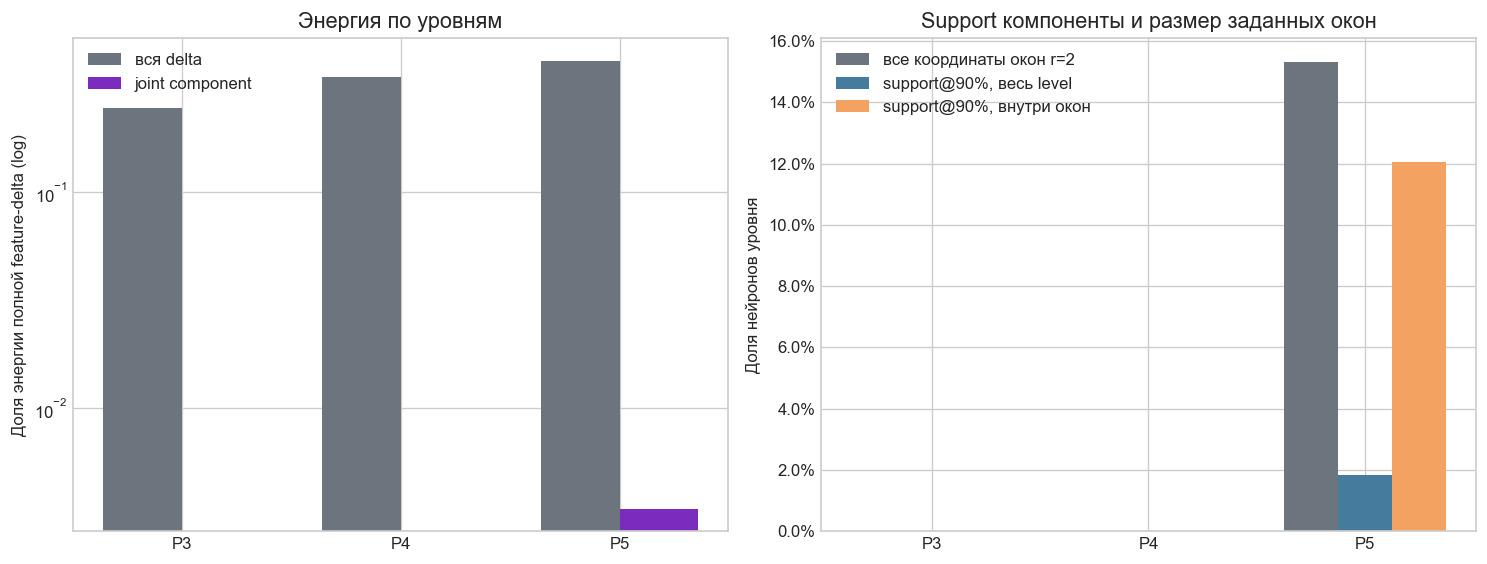

,level_name,component_energy_fraction,delta_energy_fraction,support90_fraction,support90_within_local,participation_within_local,local_window_fraction,rank
0,P3,0.00000,0.24743,0.00000,0.00000,0.00000,0.00000,0.00000
1,P4,0.00000,0.34293,0.00000,0.00000,0.00000,0.00000,0.00000
2,P5,0.00341,0.40964,0.01833,0.12062,0.02201,0.15328,23.51111


In [7]:
layer_summary = layer_df.groupby("level_name", as_index=False).agg(
    component_energy_fraction=("component_fraction_full", "mean"),
    delta_energy_fraction=("delta_fraction_full", "mean"),
    support90_fraction=("support90_fraction", "mean"),
    support90_within_local=("support90_within_local_fraction", "mean"),
    participation_within_local=("participation_within_local_fraction", "mean"),
    local_window_fraction=("local_window_fraction", "mean"),
    rank=("rank", "mean"),
)
order = [x for x in ["P3", "P4", "P5"] if x in set(layer_summary.level_name)]
layer_summary["level_name"] = pd.Categorical(layer_summary.level_name, order, ordered=True)
layer_summary = layer_summary.sort_values("level_name")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
x = np.arange(len(layer_summary)); w = .36
axes[0].bar(x-w/2, layer_summary.delta_energy_fraction, w, color=GRAY, label="вся delta")
axes[0].bar(x+w/2, layer_summary.component_energy_fraction, w, color=PURPLE, label="joint component")
axes[0].set_yscale("log")
axes[0].set_xticks(x, layer_summary.level_name)
axes[0].set_ylabel("Доля энергии полной feature-delta (log)")
axes[0].set_title("Энергия по уровням")
axes[0].legend()

w2 = .25
axes[1].bar(x-w2, layer_summary.local_window_fraction, w2, color=GRAY, label="все координаты окон r=2")
axes[1].bar(x, layer_summary.support90_fraction, w2, color=BLUE, label="support@90%, весь level")
axes[1].bar(x+w2, layer_summary.support90_within_local, w2, color=ORANGE, label="support@90%, внутри окон")
axes[1].set_xticks(x, layer_summary.level_name)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_ylabel("Доля нейронов уровня")
axes[1].set_title("Support компоненты и размер заданных окон")
axes[1].legend()
plt.tight_layout(); plt.show()

layer_summary.round(5)

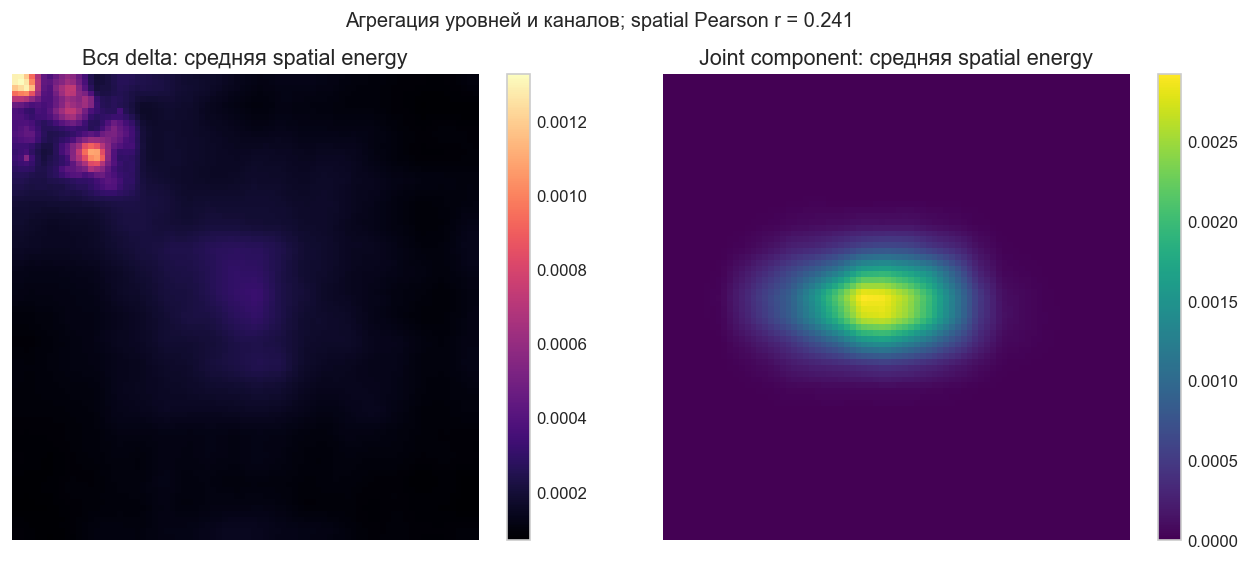

,energy_fraction,coordinate_cosine,coordinate_pearson,spatial_pearson
count,45.0000,45.0000,45.0000,45.0000
mean,0.0034,0.0578,0.0578,0.2334
std,0.0010,0.0084,0.0085,0.0886
min,0.0014,0.0378,0.0378,0.0810
10%,0.0023,0.0478,0.0478,0.1179
50%,0.0034,0.0583,0.0583,0.2410
90%,0.0045,0.0672,0.0673,0.3509
max,0.0058,0.0764,0.0765,0.4229


In [8]:
mean_component = np.mean([loaded_examples[x]["component_spatial"] for x in hidden_ids], axis=0)
mean_delta = np.mean([loaded_examples[x]["delta_spatial"] for x in hidden_ids], axis=0)
spatial_corr = safe_corr(mean_component, mean_delta)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))
for ax, image, title, cmap in [
    (axes[0], mean_delta, "Вся delta: средняя spatial energy", "magma"),
    (axes[1], mean_component, "Joint component: средняя spatial energy", "viridis"),
]:
    shown = ax.imshow(image, cmap=cmap)
    ax.set_title(title); ax.axis("off")
    plt.colorbar(shown, ax=ax, fraction=.046)
fig.suptitle(f"Агрегация уровней и каналов; spatial Pearson r = {spatial_corr:.3f}")
plt.tight_layout(); plt.show()

image_summary = pd.DataFrame([{
    "example_id": x,
    "energy_fraction": loaded_examples[x]["component_energy_fraction"],
    "coordinate_cosine": loaded_examples[x]["component_delta_cosine"],
    "coordinate_pearson": loaded_examples[x]["component_delta_pearson"],
    "spatial_pearson": safe_corr(loaded_examples[x]["component_spatial"], loaded_examples[x]["delta_spatial"]),
} for x in hidden_ids])
image_summary.describe(percentiles=[.1, .5, .9]).round(4)

**Как читать корреляцию.** Для ортогональной проекции
$\langle\delta^J,\delta\rangle=\|\delta^J\|^2$, поэтому coordinate cosine в большой
степени предопределён долей энергии: примерно $\sqrt{\rho_J}$. Он не измеряет
spatial совпадение независимо. Поэтому рядом отдельно показана корреляция карт энергии,
агрегированных по каналам.

Ниже — пять реальных случаев. Общая дельта и joint-компонента нормированы **внутри строки**:
сравнивать нужно положение hotspot, а не абсолютную яркость между изображениями.

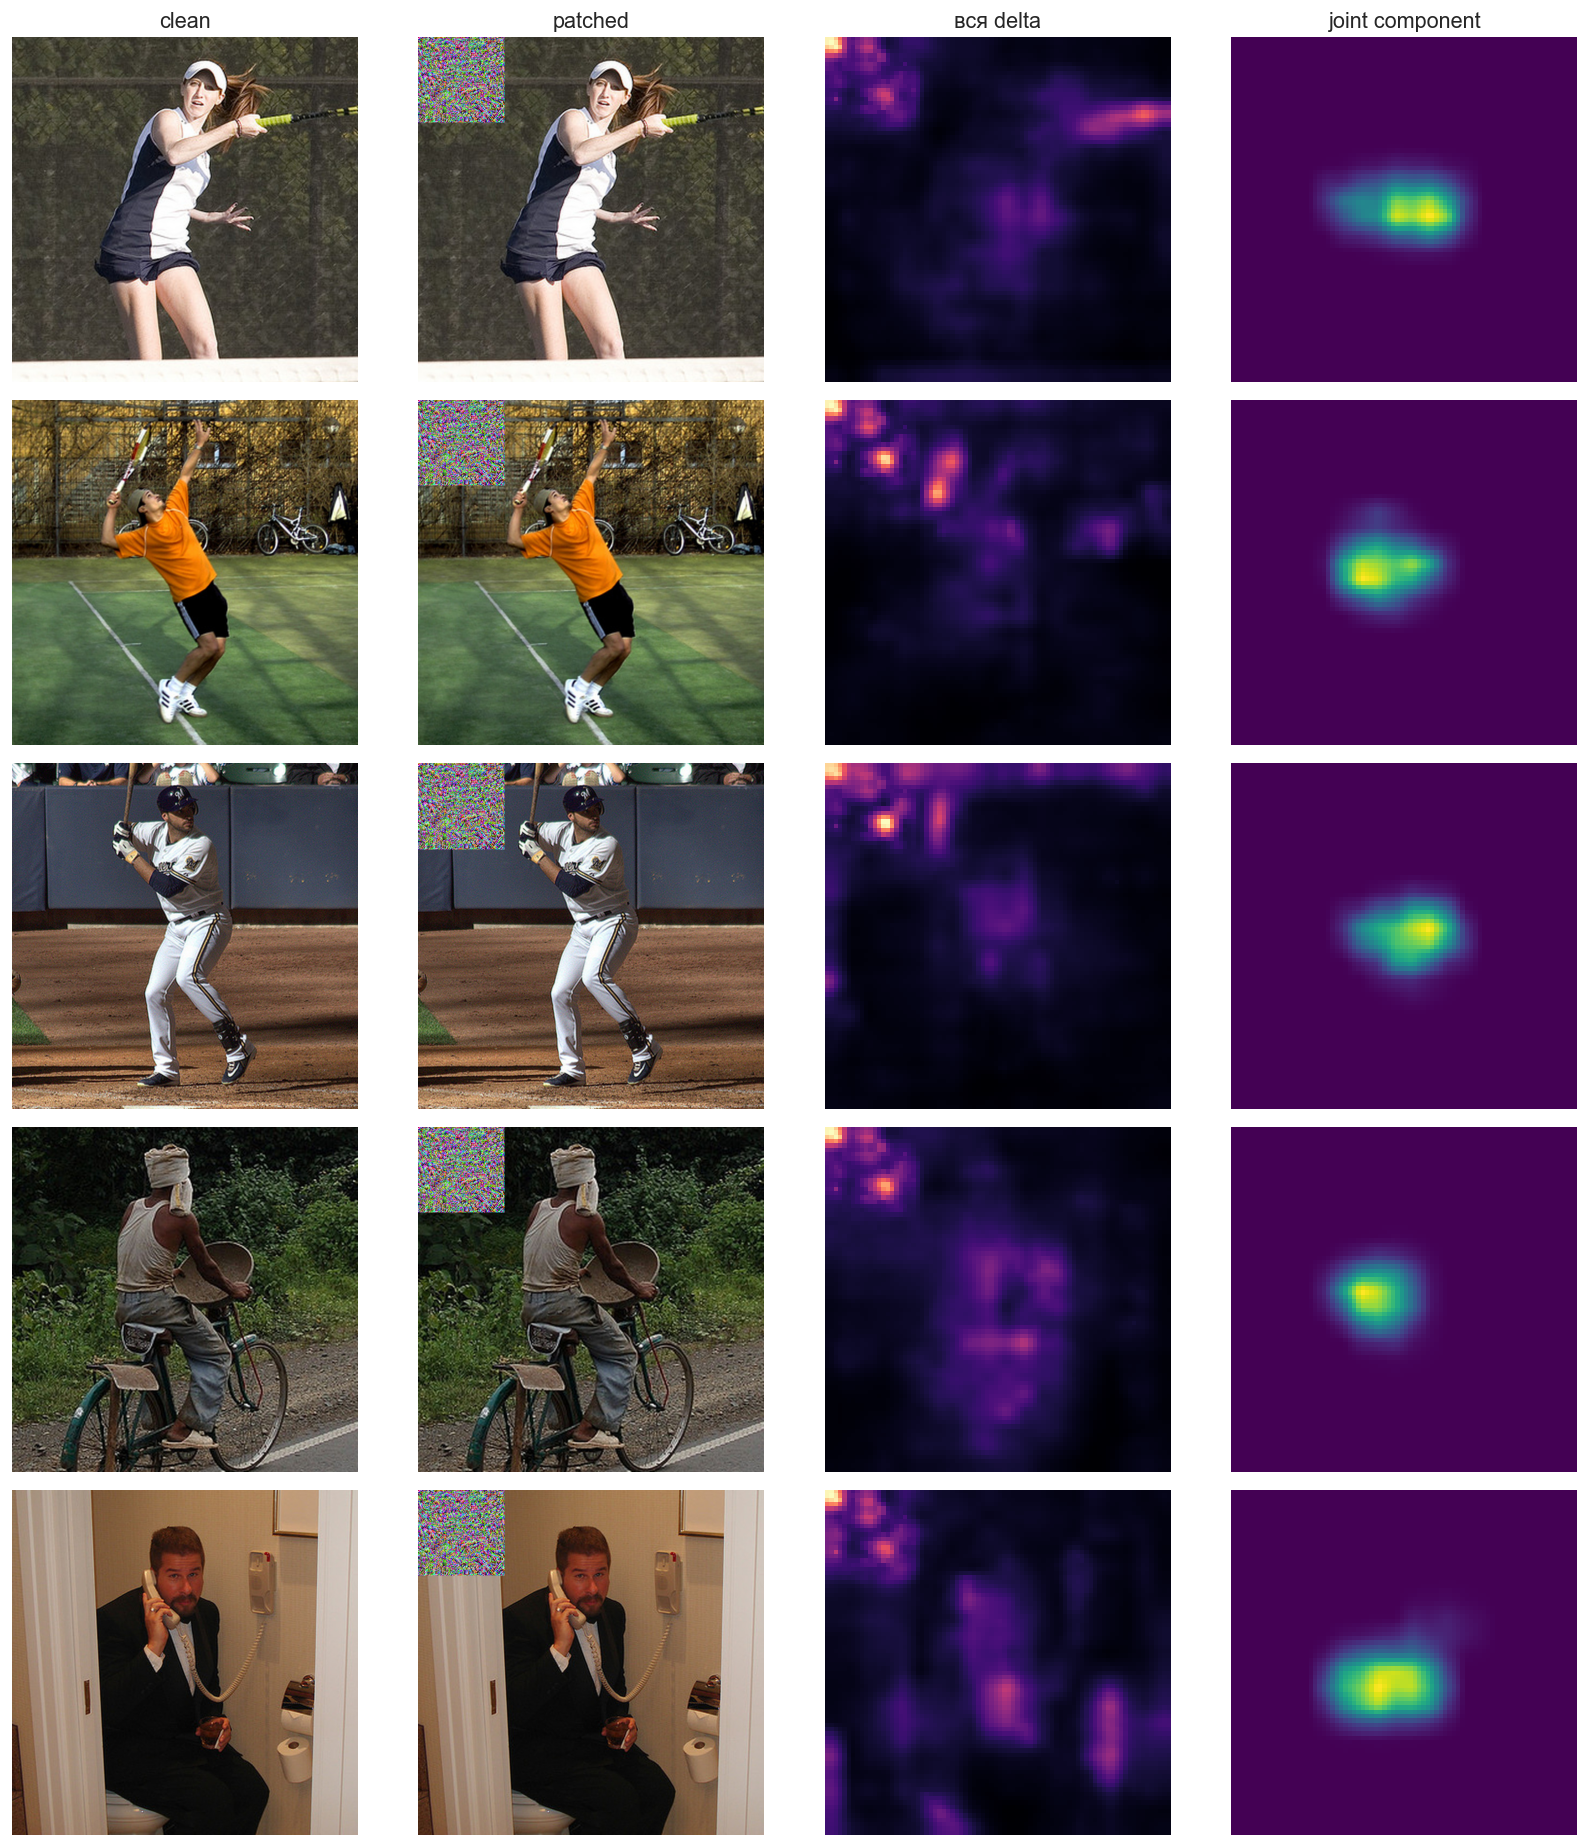

In [9]:
shown_ids = hidden_ids[:N_VISUAL]
fig, axes = plt.subplots(len(shown_ids), 4, figsize=(14, 3.1 * len(shown_ids)), squeeze=False)
for row_index, example_id in enumerate(shown_ids):
    item = loaded_examples[example_id]
    axes[row_index, 0].imshow(np.clip(item["clean_rgb"], 0, 1))
    axes[row_index, 1].imshow(np.clip(item["patched_rgb"], 0, 1))
    axes[row_index, 2].imshow(item["delta_spatial"], cmap="magma")
    axes[row_index, 3].imshow(item["component_spatial"], cmap="viridis")
    for ax in axes[row_index]: ax.axis("off")
    axes[row_index, 0].set_ylabel(example_id, rotation=90)
for ax, title in zip(axes[0], ["clean", "patched", "вся delta", "joint component"], strict=True):
    ax.set_title(title)
plt.tight_layout(); plt.show()

# 2. Увеличиваем компоненту до достаточности

Все способы стартуют с одной и той же минимальной joint-SVD компоненты (`budget=0`) и
добавляют часть ортогонального остатка. Budget задаёт долю **энергии остатка**, а по оси X
отложена фактическая энергия всей возвращённой интервенции относительно полной feature-delta.

Выбраны три способа:

1. **Delta magnitude** — oracle-верхняя планка: сначала возвращаются координаты с большой
   амплитудой реального изменения.
2. **Score IG** — прежний контроль по среднему person logit target reserve.
3. **Joint norm IG** — unsigned важность по тому же набору logits+IoU, что использует SVD.
4. **Joint aligned IG** — signed joint-вклад вдоль реально наблюдаемого изменения outputs.
   Это основной новый способ: он наиболее близок к механизму самой SVD-компоненты.
5. **Spatial cells** — joint-aligned IG ранжирует клетки, но в выбранной клетке возвращаются все
   каналы. Такой блок лучше соответствует свёрточной структуре и менее хрупок к перестановке
   соседних каналов.

При `budget=1` все стратегии обязаны совпасть с полной clean→patched дельтой; это sanity check.

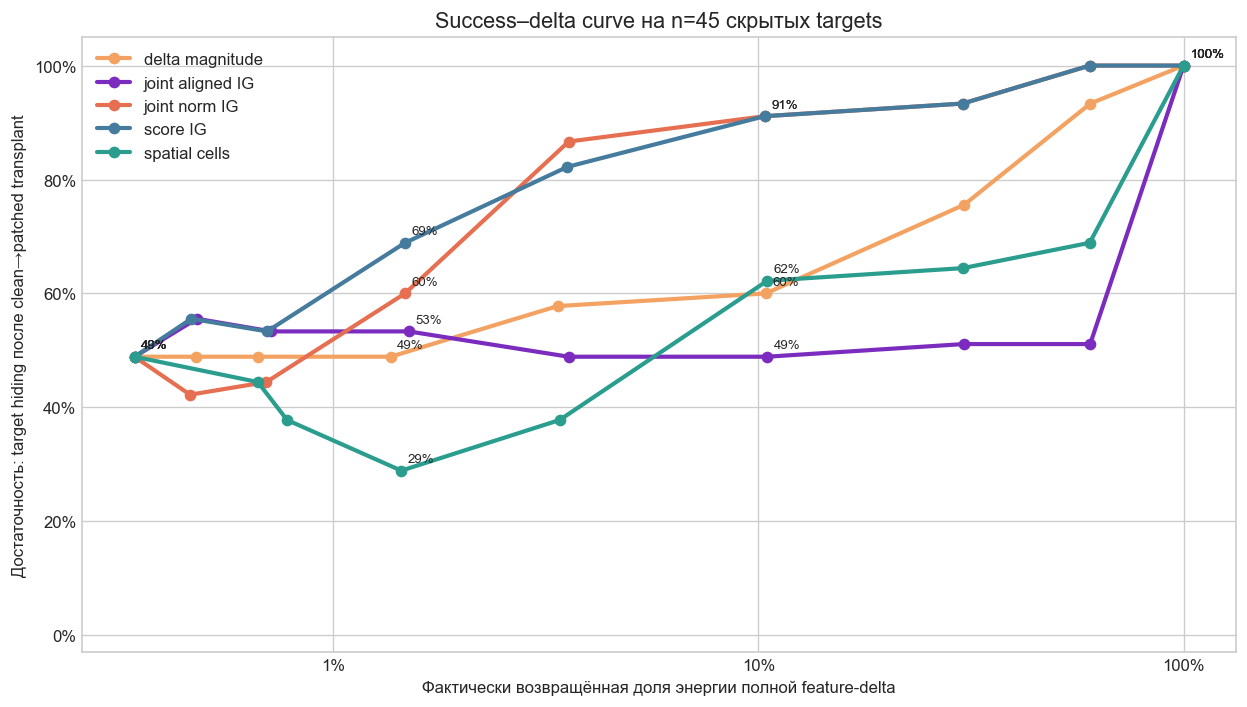

,strategy,residual_budget,hiding_rate,returned_energy,mean_selected,n
0,delta magnitude,0.000,0.48889,0.00341,0.000000e+00,45
1,delta magnitude,0.001,0.48889,0.00475,1.911110e+00,45
2,delta magnitude,0.003,0.48889,0.00665,5.711110e+00,45
3,delta magnitude,0.010,0.48889,0.01364,2.582222e+01,45
4,delta magnitude,0.030,0.57778,0.03370,1.208000e+02,45
5,delta magnitude,0.100,0.60000,0.10409,7.730222e+02,45
6,delta magnitude,0.300,0.75556,0.30459,6.246689e+03,45
7,delta magnitude,0.600,0.93333,0.60359,3.684200e+04,45
8,delta magnitude,1.000,1.00000,1.00000,1.432696e+06,45
9,joint aligned IG,0.000,0.48889,0.00341,0.000000e+00,45


In [10]:
curve = expansion_df.groupby(["strategy", "residual_budget"], as_index=False).agg(
    hiding_rate=("target_hidden", "mean"),
    returned_energy=("returned_energy_fraction", "mean"),
    mean_selected=("selected_residual_neurons", "mean"),
    n=("example_id", "nunique"),
)
colors = {
    "delta magnitude": ORANGE, "score IG": BLUE, "joint norm IG": RED,
    "joint aligned IG": PURPLE, "spatial cells": GREEN,
}
fig, ax = plt.subplots(figsize=(10.5, 6))
for strategy, frame in curve.groupby("strategy", sort=False):
    frame = frame.sort_values("residual_budget")
    ax.plot(frame.returned_energy, frame.hiding_rate, marker="o", linewidth=2.5,
            color=colors[strategy], label=strategy)
    for _, r in frame.iterrows():
        if r.residual_budget in {0, .01, .10, 1.0}:
            ax.annotate(f"{r.hiding_rate:.0%}", (r.returned_energy, r.hiding_rate),
                        xytext=(4, 5), textcoords="offset points", fontsize=8)
ax.set_xscale("symlog", linthresh=1e-4)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(-.03, 1.05)
ax.set_xlabel("Фактически возвращённая доля энергии полной feature-delta")
ax.set_ylabel("Достаточность: target hiding после clean→patched transplant")
ax.set_title(f"Success–delta curve на n={expansion_df.example_id.nunique()} скрытых targets")
ax.legend(); plt.tight_layout(); plt.show()

curve.round(5)

In [11]:
# Минимальная средняя возвращённая энергия, при которой метод достигает заданной успешности.
thresholds = []
for strategy, frame in curve.groupby("strategy"):
    frame = frame.sort_values("returned_energy")
    for target_rate in (.50, .75, .90, 1.0):
        eligible = frame[frame.hiding_rate >= target_rate]
        thresholds.append({
            "strategy": strategy, "target_success": target_rate,
            "min_mean_returned_energy": eligible.returned_energy.min() if len(eligible) else np.nan,
        })
threshold_df = pd.DataFrame(thresholds)
threshold_df.pivot(index="strategy", columns="target_success", values="min_mean_returned_energy").style.format("{:.3%}")

target_success,0.500000,0.750000,0.900000,1.000000
strategy,,,,
delta magnitude,3.370%,30.459%,60.359%,100.000%
joint aligned IG,0.477%,100.000%,100.000%,100.000%
joint norm IG,1.475%,3.580%,10.341%,60.137%
score IG,0.464%,3.554%,10.340%,60.137%
spatial cells,10.490%,100.000%,100.000%,100.000%


# 3. Joint-компонента и важные по IG нейроны

Сравниваются три определения IG-важности:

- SVD-компонента сохраняет часть **входной дельты**, видимую joint score+IoU якобиану;
- score IG использует только person logits;
- joint norm и joint aligned используют ровно те же строки person logits+IoU, что SVD.

Поэтому главный показатель — overlap верхних долей координат. Случайное ожидание для
top-$q$ против top-$q$ примерно равно $q$; линия `y=x` показана как baseline.

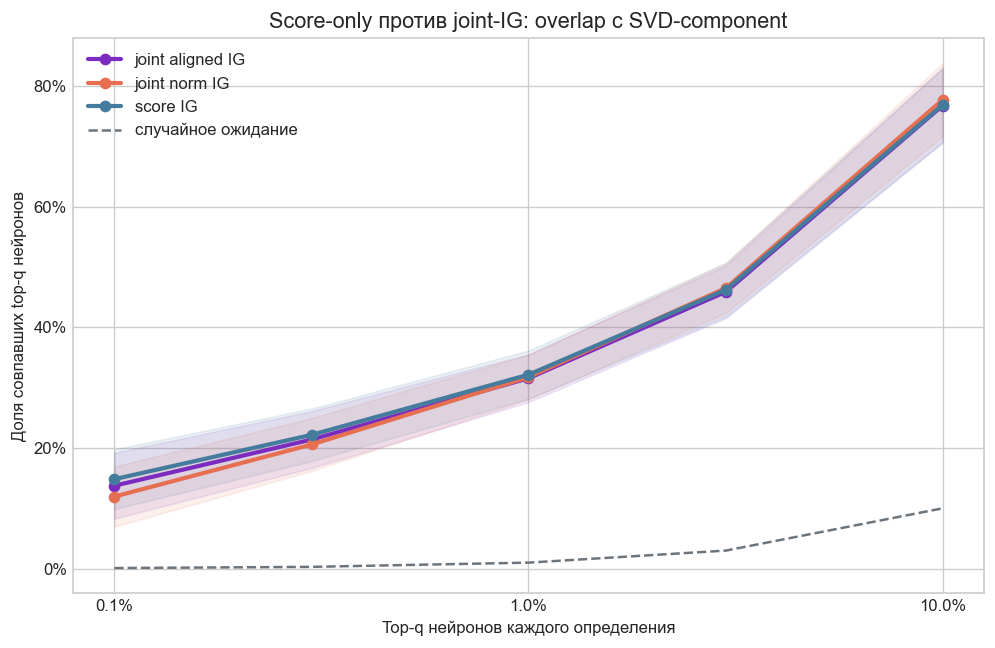

,importance,top_fraction,mean_overlap,std_overlap
0,joint aligned IG,0.001,0.1375,0.0546
1,joint aligned IG,0.003,0.2142,0.0471
2,joint aligned IG,0.010,0.3156,0.0396
3,joint aligned IG,0.030,0.4590,0.0436
4,joint aligned IG,0.100,0.7676,0.0617
5,joint norm IG,0.001,0.1195,0.0499
6,joint norm IG,0.003,0.2059,0.0438
7,joint norm IG,0.010,0.3175,0.0370
8,joint norm IG,0.030,0.4653,0.0414
9,joint norm IG,0.100,0.7770,0.0605


,score IG,joint norm IG,joint aligned IG
count,45.0000,45.0000,45.0000
mean,0.2711,0.2519,0.2458
std,0.0848,0.0861,0.0967
min,0.1011,0.0944,0.0711
10%,0.1669,0.1569,0.1435
50%,0.2618,0.2330,0.2277
90%,0.3844,0.3785,0.3713
max,0.4104,0.4016,0.4088


In [12]:
overlap = relation_df.groupby(["importance", "top_fraction"], as_index=False).agg(
    mean_overlap=("component_ig_overlap", "mean"),
    std_overlap=("component_ig_overlap", "std"),
)
importance_colors = {"score IG": BLUE, "joint norm IG": RED, "joint aligned IG": PURPLE}
fig, ax = plt.subplots(figsize=(8.4, 5.5))
for importance, frame in overlap.groupby("importance", sort=False):
    frame = frame.sort_values("top_fraction")
    color = importance_colors[importance]
    ax.plot(frame.top_fraction, frame.mean_overlap, marker="o", linewidth=2.5,
            color=color, label=importance)
    ax.fill_between(frame.top_fraction,
                    np.maximum(0, frame.mean_overlap-frame.std_overlap.fillna(0)),
                    np.minimum(1, frame.mean_overlap+frame.std_overlap.fillna(0)),
                    color=color, alpha=.10)
baseline_x = np.sort(overlap.top_fraction.unique())
ax.plot(baseline_x, baseline_x, linestyle="--", color=GRAY,
        label="случайное ожидание")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Top-q нейронов каждого определения")
ax.set_ylabel("Доля совпавших top-q нейронов")
ax.set_title("Score-only против joint-IG: overlap с SVD-component")
ax.legend(); plt.tight_layout(); plt.show()

ig_corr = pd.DataFrame([
    {
        "example_id": x,
        "score IG": loaded_examples[x]["component_score_ig_abs_pearson"],
        "joint norm IG": loaded_examples[x]["component_joint_norm_ig_abs_pearson"],
        "joint aligned IG": loaded_examples[x]["component_joint_aligned_ig_abs_pearson"],
    }
    for x in hidden_ids
])
display(overlap.round(4))
display(ig_corr.drop(columns="example_id").describe(percentiles=[.1, .5, .9]).round(4))

In [13]:
relation_by_layer = relation_df[relation_df.top_fraction.eq(.01)].merge(
    layer_df[["example_id", "level", "component_fraction_full", "support90_fraction", "rank"]],
    on=["example_id", "level"], how="left"
).groupby(["importance", "level"], as_index=False).agg(
    top1pct_overlap=("component_ig_overlap", "mean"),
    component_energy=("component_fraction_full", "mean"),
    support90=("support90_fraction", "mean"),
    rank=("rank", "mean"),
)
relation_by_layer["level"] = relation_by_layer.level.map(lambda x: f"P{x+3}")
relation_by_layer.round(5)

,importance,level,top1pct_overlap,component_energy,support90,rank
0,joint aligned IG,P5,0.31561,0.00341,0.01833,23.51111
1,joint norm IG,P5,0.31748,0.00341,0.01833,23.51111
2,score IG,P5,0.32147,0.00341,0.01833,23.51111


# 4. От нейронов обратно к пикселям

Точного обратного отображения `feature component → pixels` нет: свёрточная сеть many-to-one,
и одна feature direction может быть порождена множеством pixel perturbations. Поэтому ниже
показана **IG-backprojection** фиксированной joint-компоненты.

В каждой точке прямого pixel-path `clean→patched` берётся градиент скалярного alignment
между Detect-input features и нормированной joint-компонентой. Средний градиент умножается
на реальную pixel-delta. Полученная карта отвечает: «какие изменившиеся пиксели вдоль
наблюдавшегося пути сильнее всего проводят модель в эту feature-компоненту?»

Для каждого изображения показаны: patched input, signed attribution, модуль attribution без
подложки и тот же модуль поверх patched input. Нормировка выполняется по 99-му перцентилю
отдельно для каждого изображения.

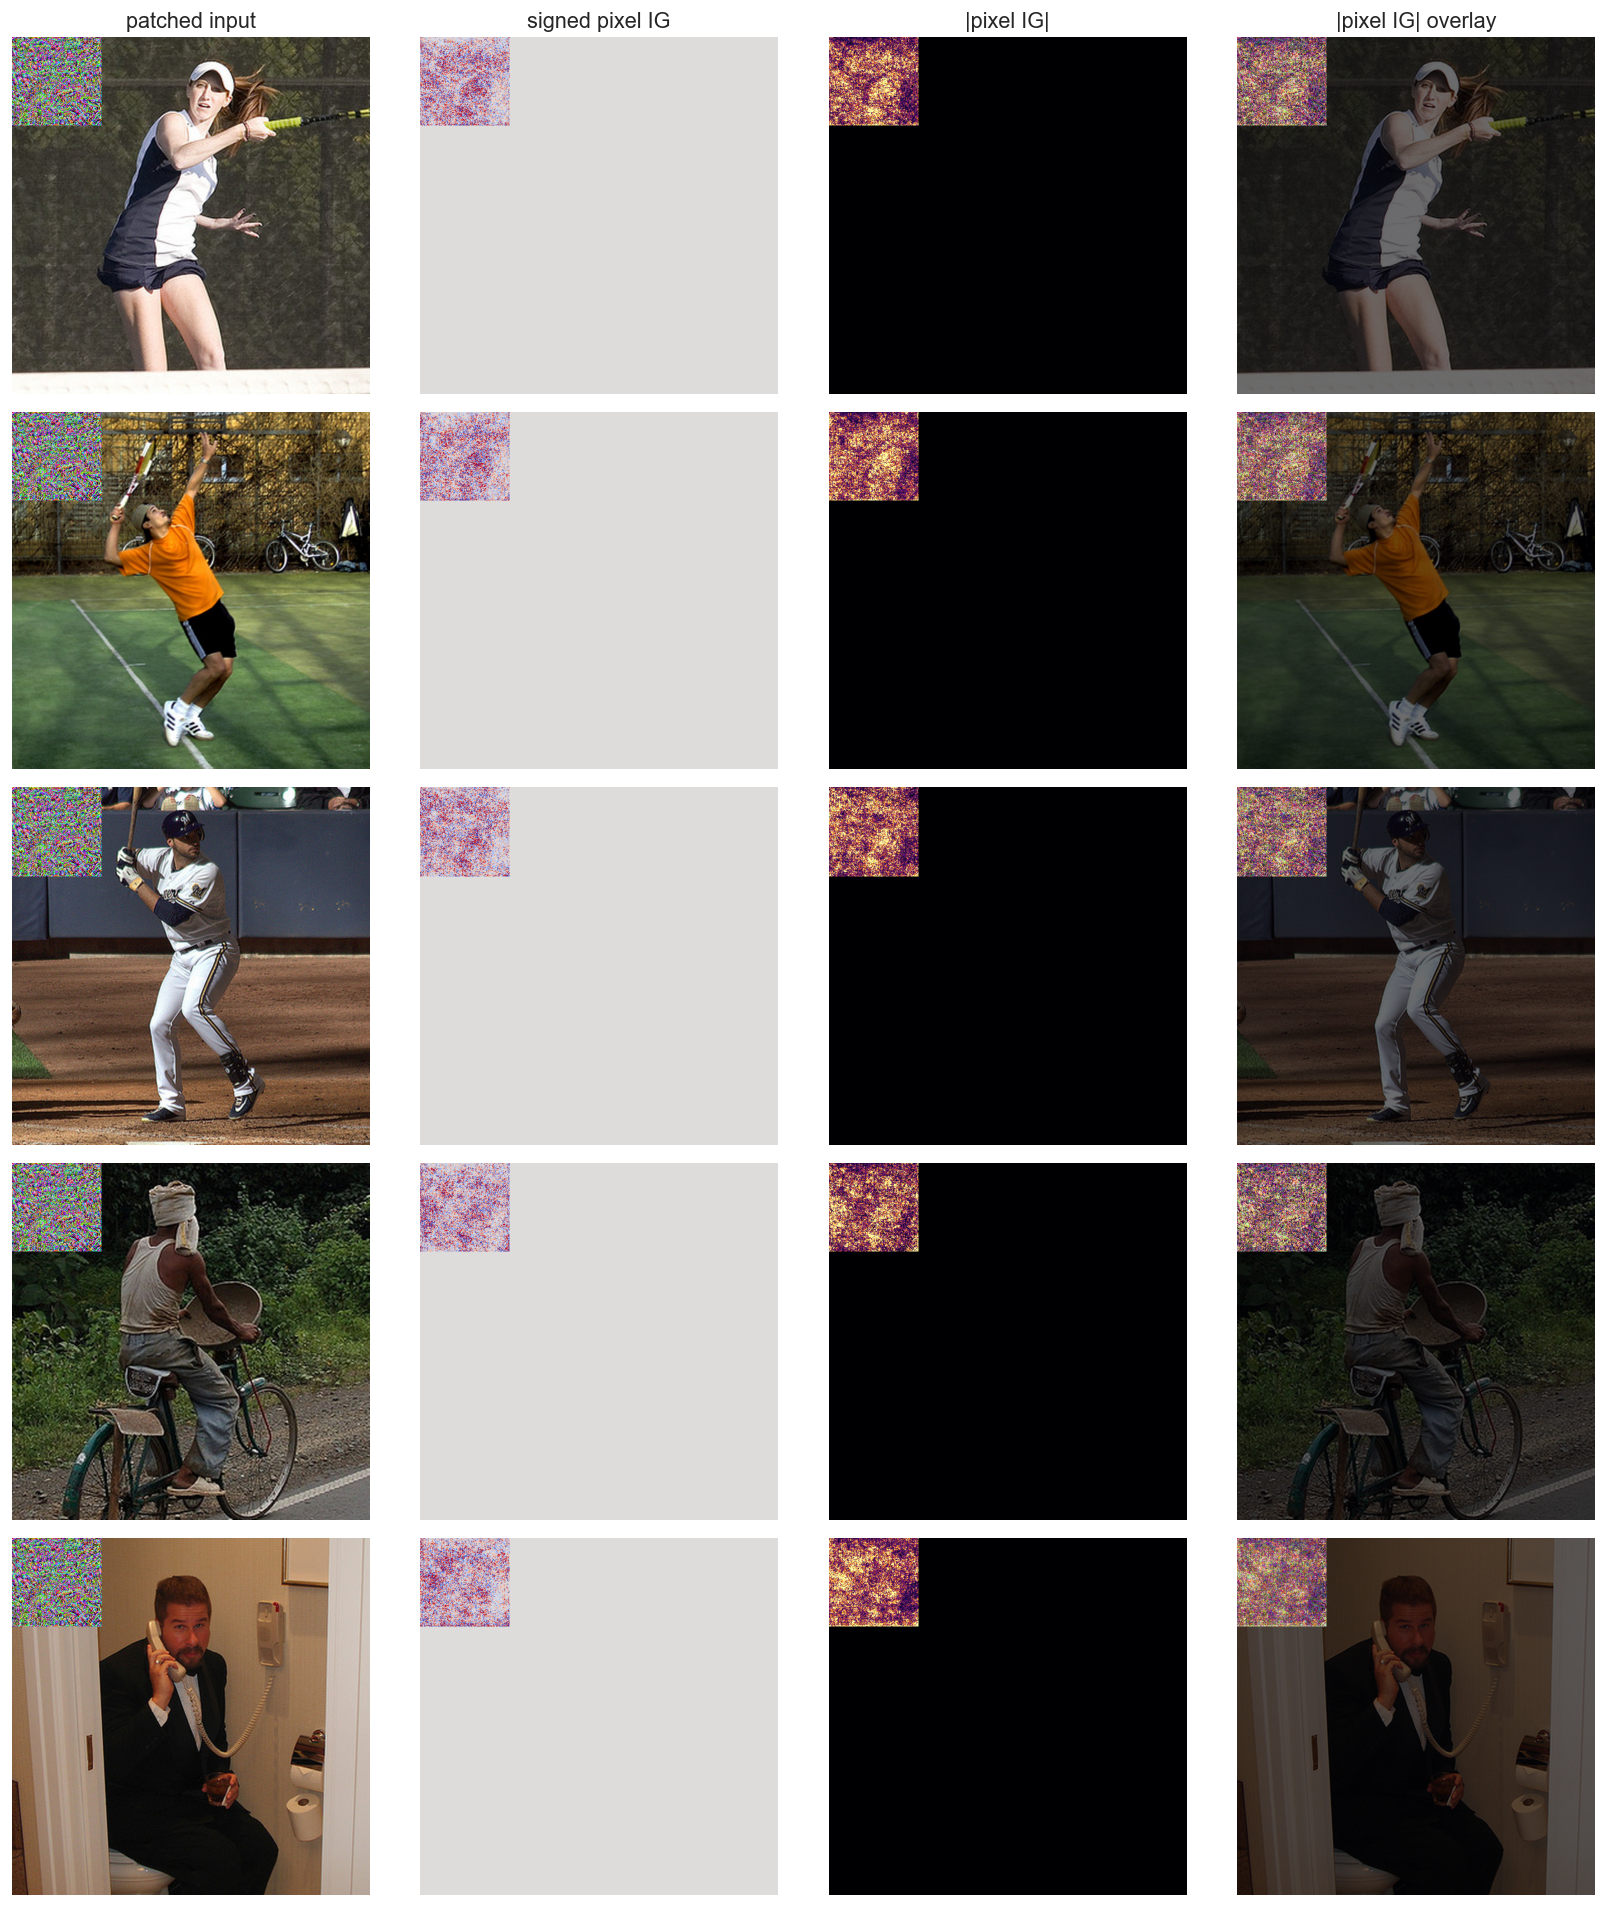

In [14]:
fig, axes = plt.subplots(len(shown_ids), 4, figsize=(14, 3.2 * len(shown_ids)), squeeze=False)
for row_index, example_id in enumerate(shown_ids):
    item = loaded_examples[example_id]
    signed = item["pixel_signed"]
    magnitude = item["pixel_magnitude"]
    scale = max(float(np.quantile(magnitude, .99)), 1e-12)
    signed_scale = max(float(np.quantile(np.abs(signed), .99)), 1e-12)

    axes[row_index, 0].imshow(np.clip(item["patched_rgb"], 0, 1))
    axes[row_index, 1].imshow(signed, cmap="coolwarm", vmin=-signed_scale, vmax=signed_scale)
    axes[row_index, 2].imshow(np.clip(magnitude / scale, 0, 1), cmap="inferno", vmin=0, vmax=1)
    axes[row_index, 3].imshow(np.clip(item["patched_rgb"], 0, 1))
    axes[row_index, 3].imshow(np.clip(magnitude / scale, 0, 1), cmap="inferno", alpha=.58, vmin=0, vmax=1)
    for ax in axes[row_index]: ax.axis("off")
    axes[row_index, 0].set_ylabel(example_id, rotation=90)
for ax, title in zip(axes[0], [
    "patched input", "signed pixel IG", "|pixel IG|", "|pixel IG| overlay"
], strict=True):
    ax.set_title(title)
plt.tight_layout(); plt.show()

## Чек-лист интерпретации результатов после запуска

1. **Все нейроны или малое подмножество?** Смотрите `support@90%` и participation ratio,
   а не только SVD rank. Низкий rank при большом support означает плотную линейную комбинацию.
2. **Где компонента?** Сопоставьте доли энергии P3/P4/P5 и spatial heatmaps с полной дельтой.
   Coordinate cosine ожидаемо мал при малой энергии; spatial correlation отвечает на другой вопрос.
3. **Что делает компоненту достаточной?** Лучший способ — тот, чья кривая выше/левее при одинаковой
   фактически возвращённой энергии. Если IG уступает magnitude, важность без амплитуды недостаточна;
   если spatial cells выигрывают, существенна согласованная локальная структура.
4. **Связь с IG.** Overlap существенно выше `y=x` означает, что SVD-проекция концентрируется в
   score-important нейронах. Слабый overlap не опровергает компоненту: она joint score+IoU и может
   быть распределена по нескольким компенсирующим координатам.
5. **Pixel view.** Это attribution наблюдавшегося clean→patched пути, не уникальная реконструкция
   патча и не доказательство, что яркие пиксели сами по себе причинно достаточны. Для такого вывода
   нужна отдельная pixel-level intervention.